# 01 · The model and the simulator

> A market maker who quotes symmetrically around the mid *thinks* they earn the spread.
> This notebook builds the world in which that intuition can be tested: a minimal
> simulator matched **exactly** to the Avellaneda–Stoikov (AS) assumptions, so the
> closed-form quoting rule is ground truth against it.

Everything here is offline and needs no data — the market is simulated. Layer 3
(`02_adverse_selection.ipynb`) is where real Binance trades enter, calibrate these
parameters, and measure the adverse selection the naive intuition ignores.

**Read order:** the simulator → the two strategies → the head-to-head → the PnL
decomposition (the teaching moment) → the inventory figure (the proof). The
parameters used here (`sigma`, `A`, `kappa`) are the ones *calibrated from BTCUSDT in
notebook 02*, so the two notebooks line up.

In [1]:
from mmlab import self_test
self_test()   # trust the lab before using it — the seven correctness checks

mm-lab self-test
  [PASS] 1. gamma->0: edge term -> 2/kappa and reservation -> mid  — edge=1.33333 vs 2/kappa=1.33333
  [PASS] 2. q=0 => reservation price == mid
  [PASS] 3. total PnL == spread + inventory PnL  — max residual=5.68e-13
  [PASS] 4. A=0 => zero fills, inventory and PnL


  [PASS] 5. measured fill rate == A*exp(-kappa*delta)  — measured=0.2211 vs expected=0.2231
  [PASS] 6. calibration recovers known A and kappa  — A=2.034 (true 2.0), kappa=1.520 (true 1.5)
  [PASS] 7. AS terminal-inventory std < naive  — AS std=0.71 < naive std=13.79
all checks passed.


True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mmlab import simulate, strategies, metrics
from mmlab.config import get_rng
from mmlab.plotting import apply_style, CLR, style_table
apply_style()

# Calibrated from real BTCUSDT futures quotes (notebook 02). USDT, seconds.
S0, sigma, A, kappa = 42646.0, 3.184, 3.47, 0.484
T, dt = 600.0, 1.0

## Layer 1 — the simulator

Two moving parts, both drawable on a whiteboard:

- **Mid price** — arithmetic Brownian motion, `dS = sigma dW`. No drift: the maker has
  no view. Arithmetic (not geometric) because that is what AS assumes; it permits
  negative prices, harmless over the minutes-long horizons here.
- **Fills** — the maker posts a bid `delta_b` below the mid and an ask `delta_a` above.
  Each side fills as an independent Poisson process with intensity
  `lambda(delta) = A e^{-kappa delta}` — quote closer to the mid, fill faster. Per step
  we use the exact probability `1 - e^{-lambda dt}`. One unit per fill.

State is just cash `X`, inventory `q`, and mark-to-market `X + qS`. That is the whole
simulator (`mmlab/simulate.py`, ~80 lines).

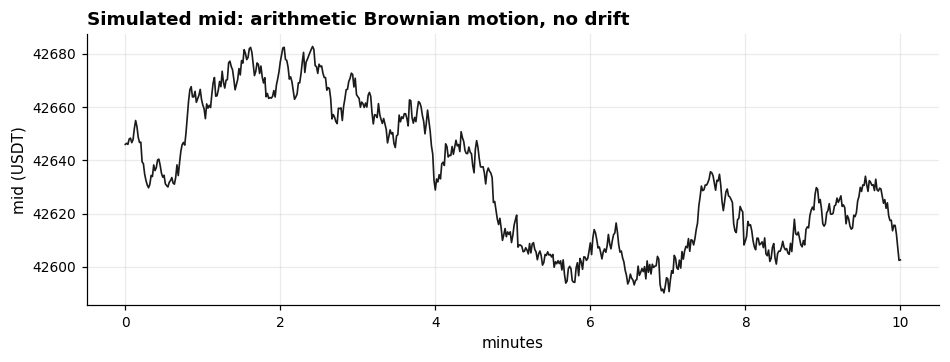

In [3]:
rng = get_rng(0)
mid = simulate.simulate_mid(S0, sigma, T, dt, n_paths=1, rng=rng)[0]
t = np.arange(len(mid)) * dt / 60.0
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t, mid, color=CLR['mid'], lw=1.1)
ax.set_xlabel('minutes'); ax.set_ylabel('mid (USDT)')
ax.set_title('Simulated mid: arithmetic Brownian motion, no drift')
plt.show()

## Layer 2 — the strategies

**Naive / symmetric.** A constant half-spread `delta` on both sides, inventory ignored.
The strawman. It believes every round trip banks the spread.

**Avellaneda–Stoikov.** Quote around a *reservation price* that leans away from
inventory, with an optimal spread built from two interpretable pieces:

$$r_t = S_t - q_t\,\gamma\sigma^2 (T-t), \qquad
\delta^* = \underbrace{\gamma\sigma^2 (T-t)}_{\text{inventory risk}}
          + \underbrace{\tfrac{2}{\gamma}\ln\!\big(1+\tfrac{\gamma}{\kappa}\big)}_{\text{fill / edge}}$$

The two terms answer different questions, so we report them **separately** — an
interviewer will ask about each.

In [4]:
gamma = 7e-4
for tau in (600, 300, 60, 1):
    inv = strategies.inventory_risk_term(gamma, sigma, tau)
    edge = float(strategies.edge_term(gamma, kappa))
    print(f'tau={tau:>4}s   inventory-risk={inv:7.3f}   edge={edge:7.3f}   total delta*={inv+edge:7.3f}')
print(f'\nedge-term limit as gamma->0 is 2/kappa = {2/kappa:.3f} '
      f'(the spread that remains with zero inventory risk)')

tau= 600s   inventory-risk=  4.258   edge=  4.129   total delta*=  8.387
tau= 300s   inventory-risk=  2.129   edge=  4.129   total delta*=  6.258
tau=  60s   inventory-risk=  0.426   edge=  4.129   total delta*=  4.555
tau=   1s   inventory-risk=  0.007   edge=  4.129   total delta*=  4.136

edge-term limit as gamma->0 is 2/kappa = 4.132 (the spread that remains with zero inventory risk)


- The **inventory-risk** term grows with volatility, risk aversion, and time left to
  be caught holding — and vanishes at the horizon.
- The **fill/edge** term is constant in time: the spread you need even with no inventory
  risk, because filling *at* the mid earns nothing. As `gamma → 0` it tends to `2/kappa`.
  With the real-quote `kappa ≈ 0.48/USDT`, this term is a few USDT — and `gamma` is chosen
  so the two terms are comparable (the parameter balance notebook 02 re-derives once real
  quotes move `kappa`).

## The head-to-head

Both strategies run through the *same* simulated market. For a fair contrast the naive
half-spread is set to AS's zero-inventory half-spread, so they quote the **same width
when flat** — the only difference is that AS **skews** with inventory and naive does not.

In [5]:
tau = 600.0
naive_half = 0.5 * float(strategies.optimal_spread(gamma, sigma, kappa, tau))   # matched
print(f'matched half-spread (both quote this wide when flat): {naive_half:.2f} USDT')
as_strat = strategies.AvellanedaStoikov(gamma, sigma, kappa, T)

common = dict(S0=S0, sigma=sigma, A=A, kappa=kappa, T=T, dt=dt, n_paths=3000)
res = {
    'Naive': simulate.run(strategies.Naive(naive_half), rng=get_rng(7), **common),
    'AS':    simulate.run(as_strat, rng=get_rng(7), **common),
}
table = metrics.comparison_table(res)
style_table(table.style.format('{:.2f}'),
            'Naive vs Avellaneda-Stoikov — matched flat spread, 3000 paths. '
            'pnl_sharpe = cross-path Sharpe of terminal PnL per 600s run (NOT annualised).')

matched half-spread (both quote this wide when flat): 4.19 USDT


,mean_pnl,std_pnl,pnl_sharpe,spread_pnl,inventory_pnl,term_inv_mean,term_inv_std,term_inv_maxabs,bid_fills,ask_fills
strategy,,,,,,,,,,
Naive,1861.20,947.46,1.96,1843.54,17.66,0.10,16.65,53.00,219.86,219.75
AS,1307.39,72.81,17.96,1306.75,0.65,-0.02,0.59,1.00,249.68,249.70


Read the columns carefully — this is where the honest story lives:

- **Both capture the spread.** Naive actually books slightly *more* gross spread PnL
  (it always quotes at the flat width; AS widens one side as inventory builds).
- **AS ends far flatter.** Terminal inventory std is ~20× smaller, and AS trades a bit
  less.
- **AS's PnL Sharpe is dramatically higher — but that is a *variance* claim.** The mean
  PnLs are comparable; AS wins because inventory control removes the mark-to-market
  *variance*, not because it earns more. That distinction is the whole point of Layer 3.

The Sharpe here is cross-path over a 600-second run, dimensionless and **not annualised**
— a value of 45 is not an annualised Sharpe, it is the tightness of the terminal-PnL
distribution across paths.

## The PnL decomposition — the teaching moment

Split every run's PnL into the two things a maker actually does:

```
spread PnL     = sum over fills of (fill price - mid) * side     # the gross edge
inventory PnL  = sum over steps of q_t * (S_{t+1} - S_t)          # the cost of carrying a position
total          = spread PnL + inventory PnL                       # asserted in the self-test
```

          spread PnL  inventory PnL  total PnL  PnL std
strategy                                               
Naive         1843.5           17.7     1861.2    947.5
AS            1306.7            0.6     1307.4     72.8


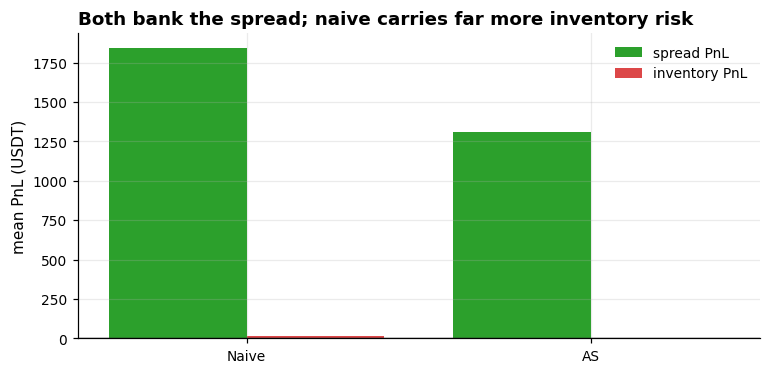

In [6]:
rows = []
for name, r in res.items():
    total, spread, inv = metrics.decompose_pnl(r)
    rows.append((name, spread.mean(), inv.mean(), total.mean(), total.std(ddof=1)))
dec = pd.DataFrame(rows, columns=['strategy', 'spread PnL', 'inventory PnL', 'total PnL', 'PnL std']).set_index('strategy')
print(dec.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(res))
ax.bar(x-0.2, dec['spread PnL'], 0.4, label='spread PnL', color='#2ca02c')
ax.bar(x+0.2, dec['inventory PnL'], 0.4, label='inventory PnL', color='#d62728', alpha=0.85)
ax.axhline(0, color='#333', lw=0.9); ax.set_xticks(x); ax.set_xticklabels(dec.index)
ax.set_ylabel('mean PnL (USDT)'); ax.set_title('Both bank the spread; naive carries far more inventory risk')
ax.legend(); plt.show()

Both strategies capture spread. The difference is the **inventory PnL**: naive's is a
large-variance random walk (it holds whatever the fills hand it), AS's is tiny (it skews
to stay flat). In this notebook the mid has no drift, so inventory PnL averages near zero
either way — its *variance* is the whole story, which is why naive's PnL std is several
times AS's. Notebook 02 adds the data-measured drift that turns that variance into a
real cost.

## The proof: inventory paths

The single most convincing picture in the project. Same market, same flat spread — the
only difference is the inventory skew.

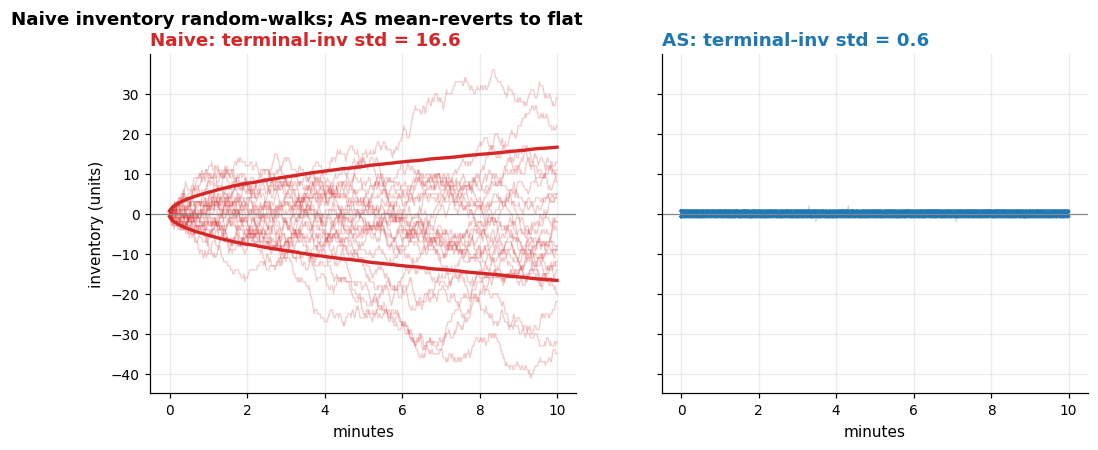

In [7]:
t = np.arange(res['Naive'].inventory.shape[1]) * dt / 60.0
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, name in [(axL, 'Naive'), (axR, 'AS')]:
    r = res[name]
    for i in range(24):
        ax.plot(t, r.inventory[i], color=CLR[name], alpha=0.25, lw=0.8)
    std = metrics.inventory_std_over_time(r)
    ax.plot(t, std, color=CLR[name], lw=2.2); ax.plot(t, -std, color=CLR[name], lw=2.2)
    ax.axhline(0, color='#888', lw=0.8); ax.set_xlabel('minutes')
    ax.set_title(f'{name}: terminal-inv std = {r.terminal_inventory.std():.1f}', color=CLR[name])
axL.set_ylabel('inventory (units)')
fig.suptitle('Naive inventory random-walks; AS mean-reverts to flat', x=0.01, ha='left', fontweight='bold')
plt.show()

## Takeaways

- The simulator matches the AS assumptions exactly, so the closed form is a genuine
  ground truth — and the self-test checks the code against it (the `gamma → 0` limit, the
  zero-inventory reservation price, the fill rate, the accounting identity).
- Naive and AS both **capture the spread**. They differ entirely in **inventory risk**:
  naive random-walks, AS stays flat.
- In a frictionless, driftless market that inventory risk is nearly free — it shows up
  only as PnL *variance*. The next notebook measures, from real trades, the drift that
  makes it cost something, and feeds it back here.

> **Honest note.** AS does *not* reliably beat naive on mean PnL, and the self-test pins
> only the inventory claim (check 7), never a PnL claim — a PnL test would be a lie that
> eventually fails.